# Etapa 5 (§3.5) — Detección y adaptación al concept drift
**Proyecto 1 · Reingreso a 30 días (Diabetes 130-US)**

Parte del modelo elegido en la Etapa 3 (`04_modelado.ipynb`) y aborda la §3.5 de la consigna: detección de cambios de distribución (PSI/KS), evaluación del impacto del drift bajo distintos tamaños de ventana, estrategias de adaptación por **ventanas deslizantes / reentrenamiento** (E2–E4) y reflexión sobre los riesgos de un sistema dinámico. Incluye además la capa de decisión (incertidumbre, costos, DCA), la auditoría de equidad y la explicabilidad (SHAP) que evalúan el sistema ya adaptado.

> La **Etapa 4 (§3.4 Despliegue del sistema)** —arquitectura de implementación, flujo de datos, frecuencia de actualización, autonomía y retos de escalabilidad/costos/integración— es una **propuesta de diseño** que va en el documento técnico, no en este notebook.

## 1. Configuración y parámetros de decisión

In [1]:
import os, time, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.special import logit, expit

import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import xgboost as xgb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

SEED = 42
rng = np.random.default_rng(SEED)
os.makedirs("../resultados", exist_ok=True)
print("sklearn", sklearn.__version__, "| xgboost", xgb.__version__)

sklearn 1.6.1 | xgboost 3.2.0


In [2]:
# ---------------- Ejecución ----------------
MODO_RAPIDO   = False      # True: menos bootstrap y menos réplicas (para probar)
DIR_PREP      = "../data/processed"  # salida del notebook de Análisis (train/validacion/test)
RUTA_RAW      = "../data/raw/diabetic_data.csv"         # solo para recuperar 'race' en la auditoría de equidad
N_BLOQUES     = 10         # pseudo-periodos (20 periodos del prep -> 10 bloques de 2 periodos)
EMBARGO       = 2000       # = label_delay_encuentros calibrado en 03_preprocesamiento (metadata_preparacion.json); evita el leak temporal ya detectado
BLOQUES_TRAIN_INICIAL = 2  # E1: se entrena en B1-B2
FRAC_CALIB    = 0.20       # último 20% (temporal) de la ventana de entrenamiento -> calibración
B_BOOT        = 100 if MODO_RAPIDO else 500   # remuestreos para IC95%
N_REPLICAS_INCERT = 3 if MODO_RAPIDO else 10  # réplicas bootstrap para incertidumbre

# ---------------- Parámetros de decisión ----------------
C_R   = 16037.0   # costo de un reingreso (US$)            [Evidencia: Ghabowen et al., 2024]
C_I   = 550.0     # costo intervención Alto Riesgo (US$)   [Supuesto]
E     = 0.18      # eficacia intervención Alto (RR 0.82)   [Evidencia: Leppin et al., 2014]
C_M   = 50.0      # costo intervención Moderado (US$)      [Supuesto]
E_M   = 0.03      # eficacia intervención Moderado         [Supuesto]
E_SENSIBILIDAD = [0.12, 0.18, 0.38]                        # Drincic 2017 / Leppin 2014 / escenario 10:1
K_ALTO = 0.15     # máximo de altas marcadas Alto Riesgo por bloque [Supuesto]
FACTOR_OCUPACION = 1.25  # escenario ocupación > 85%: costo efectivo del reingreso +25% [Supuesto]

def p_estrella(c_i=C_I, c_r=C_R, e=E):
    "Umbral óptimo intervenir vs. no intervenir: p* = C_i / (C_r · e)"
    return c_i / (c_r * e)

def umbrales(c_r=C_R, c_i=C_I, e=E, c_m=C_M, e_m=E_M):
    "t1: Bajo->Moderado ; t2: Moderado->Alto (de la matriz de costos)"
    t1 = c_m / (c_r * e_m)
    t2 = (c_i - c_m) / (c_r * (e - e_m))
    return t1, t2

T1, T2 = umbrales()
tabla_param = pd.DataFrame([{
    "e": e, "p*": p_estrella(e=e), "peso FN:FP equiv.": (1 - p_estrella(e=e)) / p_estrella(e=e),
    "t1": umbrales(e=e)[0], "t2": umbrales(e=e)[1]} for e in E_SENSIBILIDAD]).round(3)
print(f"Caso base -> p* = {p_estrella():.3f} | t1 = {T1:.3f} | t2 = {T2:.3f} | "
      f"t2 con ocupación alta = {umbrales(c_r=C_R*FACTOR_OCUPACION)[1]:.3f}")
tabla_param

Caso base -> p* = 0.191 | t1 = 0.104 | t2 = 0.208 | t2 con ocupación alta = 0.166


,e,p*,peso FN:FP equiv.,t1,t2
0,0.12,0.286,2.499,0.104,0.346
1,0.18,0.191,4.248,0.104,0.208
2,0.38,0.090,10.080,0.104,0.089


## 2. Carga del dataset limpio (con `race` para equidad)

In [3]:
# --- Carga del dataset limpio (train/validacion/test del notebook de Análisis) ---
partes = {n: pd.read_csv(f"{DIR_PREP}/{n}.csv") for n in ["train", "validacion", "test"]}
df = pd.concat(partes.values(), ignore_index=True).sort_values("t_idx").reset_index(drop=True)
df["pos"] = np.arange(len(df))            # orden pseudo-temporal (t_idx del prep)
df["y"]   = df["target"].astype(int)       # target = 1 si readmitted == '<30'

# 'race' no está en el dataset limpio; se recupera SOLO para auditar equidad (NO es feature del modelo)
raw_race = pd.read_csv(RUTA_RAW, na_values=["?"], keep_default_na=False,
                       low_memory=False)[["encounter_id", "race"]]
df = df.merge(raw_race, on="encounter_id", how="left")
df["race"] = df["race"].fillna("Desconocido")

print("Forma:", df.shape, "| pacientes únicos:", df.patient_nbr.nunique(),
      "| prevalencia <30:", round(df.y.mean(), 4))
print("Periodos:", sorted(df.period.unique()), "| filas por conjunto:",
      {n: len(p) for n, p in partes.items()})
faltantes = df.isna().mean().sort_values(ascending=False)
faltantes = faltantes[faltantes > 0].to_frame("% faltante").mul(100).round(2)
display(faltantes)

Forma: (95451, 67) | pacientes únicos: 68055 | prevalencia <30: 0.114
Periodos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)] | filas por conjunto: {'train': 57709, 'validacion': 17912, 'test': 19830}


,% faltante
max_glu_serum,94.67
A1Cresult,83.10
prev_time_in_hospital,70.72
log_gap_prev_encounter,70.72
roll3_time_in_hospital,70.72
prev_number_diagnoses_capped,70.72
prev_n_meds_active,70.72
prev_num_medications,70.72
ctx_readmit_rate,2.62
ctx_inpatient_mean,0.52


In [4]:
df["edad"]       = df["age_num"]                 # punto medio del rango (auditoría de equidad)
df["edad_70mas"] = (df.edad >= 70).astype(int)
df["bloque"]     = df.period // 2 + 1            # 10 bloques pseudo-temporales

# Categóricas con NaN estructural (laboratorio no solicitado) -> categoría explícita
for c in ["max_glu_serum", "A1Cresult"]:
    df[c] = df[c].fillna("None")
print("Prevalencia <30 días:", round(df.y.mean(), 4), "| bloques:", sorted(df.bloque.unique()))

Prevalencia <30 días: 0.114 | bloques: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


## 3. Definición de variables

In [5]:
# --- Familias de variables según el diccionario del dataset limpio (metadata_preparacion.json) ---
USAR_CONTEXTO = False  # ctx_*/rel_* son proxy del periodo (Secc. 10.5 / 03_preprocesamiento); degradan generalizacion -> excluidas

NUM_ESTATICAS = ["age_num", "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
                 "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses_capped",
                 "service_utilization", "n_meds_active", "n_meds_changed", "meds_per_day", "labs_per_day",
                 "n_comorbidity_groups", "dm_primary", "dm_complicated", "a1c_tested", "a1c_high",
                 "glu_tested", "glu_high"]
NUM_TEMPORALES = ["enc_seq", "is_returning", "prev_readmit30", "hist_n_readmit30", "hist_rate_readmit30",
                  "prev_time_in_hospital", "prev_num_medications", "prev_number_diagnoses_capped",
                  "prev_n_meds_active", "delta_num_medications", "delta_n_meds_active",
                  "roll3_time_in_hospital", "log_gap_prev_encounter", "prev_discharge_snf"]
NUM_CONTEXTO = ["ctx_readmit_rate", "ctx_inpatient_mean", "ctx_a1c_rate", "rel_number_diagnoses", "rel_num_medications"]
VARS_CAT = ["gender", "admission_type_grp", "discharge_grp", "admission_source_grp", "specialty_grp",
            "diag_1_grp", "diag_2_grp", "diag_3_grp", "max_glu_serum", "A1Cresult",
            "insulin", "metformin", "glipizide", "glyburide", "pioglitazone", "rosiglitazone",
            "glimepiride", "change", "diabetesMed"]

VARS_NUM = NUM_ESTATICAS + NUM_TEMPORALES + (NUM_CONTEXTO if USAR_CONTEXTO else [])
VARS_CAT = [c for c in VARS_CAT if df[c].nunique() > 1]
FEATURES = VARS_NUM + VARS_CAT   # 'race' NO se incluye (solo auditoría de equidad)
print(f"{len(VARS_NUM)} numéricas + {len(VARS_CAT)} categóricas = {len(FEATURES)} variables "
      f"(contexto {'incluido' if USAR_CONTEXTO else 'excluido'})")
print("Features con NaN (se imputan por mediana en ElasticNet/RF; XGBoost las maneja nativamente):",
      [c for c in VARS_NUM if df[c].isna().any()])
df[FEATURES].head(3)

35 numéricas + 19 categóricas = 54 variables (contexto excluido)


Features con NaN (se imputan por mediana en ElasticNet/RF; XGBoost las maneja nativamente): ['prev_time_in_hospital', 'prev_num_medications', 'prev_number_diagnoses_capped', 'prev_n_meds_active', 'roll3_time_in_hospital', 'log_gap_prev_encounter']


,age_num,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses_capped,service_utilization,n_meds_active,n_meds_changed,meds_per_day,labs_per_day,n_comorbidity_groups,dm_primary,dm_complicated,a1c_tested,a1c_high,glu_tested,glu_high,enc_seq,is_returning,prev_readmit30,hist_n_readmit30,hist_rate_readmit30,prev_time_in_hospital,prev_num_medications,prev_number_diagnoses_capped,prev_n_meds_active,delta_num_medications,delta_n_meds_active,roll3_time_in_hospital,log_gap_prev_encounter,prev_discharge_snf,gender,admission_type_grp,discharge_grp,admission_source_grp,specialty_grp,diag_1_grp,diag_2_grp,diag_3_grp,max_glu_serum,A1Cresult,insulin,metformin,glipizide,glyburide,pioglitazone,rosiglitazone,glimepiride,change,diabetesMed
0,85,13,68,2,28,0,0,0,8,0,2,0,2.153846,5.230769,1,0,0,0,0,0,0,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,Female,Emergency/Urgent,Home,Transfer,Missing,Circulatory,Circulatory,Other,None,None,Steady,No,Steady,No,No,No,No,Ch,Yes
1,95,12,33,3,18,0,0,0,8,0,2,0,1.500000,2.750000,3,0,0,0,0,0,0,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,Female,Elective,SNF/long-term,Transfer,InternalMedicine,Circulatory,Neoplasms,Respiratory,None,None,Steady,No,No,No,No,Steady,No,Ch,Yes
2,45,1,51,0,8,0,0,0,5,0,2,0,8.000000,51.000000,2,0,0,0,0,0,0,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,Male,Emergency/Urgent,Home,Emergency room,Missing,Neoplasms,Neoplasms,Diabetes,None,None,Steady,No,Steady,No,No,No,No,Ch,Yes


## 4. Métricas y utilidades de evaluación

In [6]:
_SK18 = tuple(int(x) for x in sklearn.__version__.split(".")[:2]) >= (1, 8)

def logistica_sin_penalizacion():
    return LogisticRegression(C=np.inf, max_iter=1000) if _SK18 else LogisticRegression(penalty=None, max_iter=1000)

def pendiente_intercepto(y, p):
    lp = logit(np.clip(p, 1e-6, 1 - 1e-6))
    pendiente = logistica_sin_penalizacion().fit(lp.reshape(-1, 1), y).coef_[0, 0]
    # intercepto de calibración (calibration-in-the-large): logit(P) = a + lp
    def nll(a):
        q = np.clip(expit(a + lp), 1e-9, 1 - 1e-9)
        return -np.sum(y * np.log(q) + (1 - y) * np.log(1 - q))
    intercepto = minimize_scalar(nll, bounds=(-5, 5), method="bounded").x
    return pendiente, intercepto

def ece(y, p, bins=10):
    grupos = pd.qcut(p, bins, labels=False, duplicates="drop")
    d = pd.DataFrame({"y": y, "p": p, "g": grupos}).groupby("g").agg(y=("y", "mean"), p=("p", "mean"), n=("y", "size"))
    return float(np.sum(d.n * (d.y - d.p).abs()) / d.n.sum())

def metricas(y, p):
    y = np.asarray(y); p = np.asarray(p)
    prev = y.mean()
    pend, inter = pendiente_intercepto(y, p)
    brier = brier_score_loss(y, p)
    return {"n": len(y), "prevalencia": prev,
            "ROC_AUC": roc_auc_score(y, p), "PR_AUC": average_precision_score(y, p),
            "lift_PR": average_precision_score(y, p) / prev,
            "Brier": brier, "BSS": 1 - brier / (prev * (1 - prev)),
            "pendiente_cal": pend, "intercepto_cal": inter, "ECE": ece(y, p)}

def ic_bootstrap(y, p, fn, B=B_BOOT, semilla=SEED):
    y = np.asarray(y); p = np.asarray(p)
    r = np.random.default_rng(semilla); vals = []
    for _ in range(B):
        i = r.integers(0, len(y), len(y))
        if y[i].min() == y[i].max(): continue
        vals.append(fn(y[i], p[i]))
    return np.percentile(vals, [2.5, 97.5])

def beneficio_neto(y, p, pt):
    y = np.asarray(y); marca = np.asarray(p) >= pt; n = len(y)
    vp = np.sum(marca & (y == 1)); fp = np.sum(marca & (y == 0))
    return vp / n - fp / n * pt / (1 - pt)

def costo_por_1000(y, intervenir, e=E, c_i=C_I, c_r=C_R):
    y = np.asarray(y); m = np.asarray(intervenir).astype(bool)
    vp = np.sum(m & (y == 1)); fp = np.sum(m & (y == 0)); fn = np.sum(~m & (y == 1))
    return 1000 * (c_i * (vp + fp) + c_r * (fn + vp * (1 - e))) / len(y)

## 5. Modelos y calibración

In [7]:
def construir(nombre, params):
    if nombre == "ElasticNet":
        pre = ColumnTransformer([
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), VARS_NUM),
            ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30), VARS_CAT)])
        kw = dict(solver="saga", max_iter=300, tol=1e-3, random_state=SEED, **params)
        if not _SK18: kw["penalty"] = "elasticnet"
        clf = LogisticRegression(**kw)
    elif nombre == "RandomForest":
        pre = ColumnTransformer([
            ("num", SimpleImputer(strategy="median"), VARS_NUM),
            ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30), VARS_CAT)])
        clf = RandomForestClassifier(n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=SEED, **params)
    elif nombre == "XGBoost":
        pre = ColumnTransformer([
            ("num", "passthrough", VARS_NUM),   # XGBoost maneja NaN de forma nativa
            ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30), VARS_CAT)])
        clf = xgb.XGBClassifier(learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                                min_child_weight=5, reg_lambda=1.0, tree_method="hist",
                                eval_metric="logloss", n_jobs=-1, random_state=SEED, **params)
    else:
        raise ValueError(nombre)
    return Pipeline([("pre", pre), ("clf", clf)])

def ajustar_pipeline(nombre, params, X, y, semilla=None):
    pipe = construir(nombre, params)
    if semilla is not None:
        pipe.set_params(clf__random_state=semilla)
    pipe.fit(X, y)
    return pipe

class ModeloCalibrado:
    """Entrena en el 80% inicial de la ventana. Calibra en el 20% final probando dos metodos
    y usando el que minimice el Brier en un sub-holdout interno (70/30 temporal de la ventana
    de calibracion): Platt scaling (Platt, 1999) e Isotonic Regression (Zadrozny & Elkan, 2002).
    Comparacion de ambos metodos en clasificadores: Niculescu-Mizil & Caruana (2005)."""
    def __init__(self, nombre, params, semilla=None, bootstrap=False):
        self.nombre, self.params, self.semilla, self.bootstrap = nombre, params, semilla, bootstrap
    def _platt(self, s, y):
        return logistica_sin_penalizacion().fit(logit(np.clip(s, 1e-6, 1 - 1e-6)).reshape(-1, 1), y)
    def fit(self, X, y):
        corte = int(len(X) * (1 - FRAC_CALIB))
        Xf, yf = X.iloc[:corte], y.iloc[:corte]
        if self.bootstrap:  # replica para incertidumbre
            i = np.random.default_rng(self.semilla).integers(0, corte, corte)
            Xf, yf = Xf.iloc[i], yf.iloc[i]
        self.pipe = ajustar_pipeline(self.nombre, self.params, Xf, yf, self.semilla)
        Xc, yc = X.iloc[corte:], y.iloc[corte:]
        s_cal = self.pipe.predict_proba(Xc)[:, 1]
        yc_arr = yc.values

        # --- Seleccion Platt vs. Isotonic dentro de la propia ventana de calibracion ---
        corte_sel = int(len(s_cal) * 0.7)
        self.metodo_cal = "platt"
        y_fit_chk, y_sel_chk = yc_arr[:corte_sel], yc_arr[corte_sel:]
        if len(y_sel_chk) >= 30 and len(set(y_fit_chk)) > 1 and len(set(y_sel_chk)) > 1:
            s_fit, y_fit = s_cal[:corte_sel], y_fit_chk
            s_sel, y_sel = s_cal[corte_sel:], y_sel_chk
            b_platt = brier_score_loss(y_sel, self._platt(s_fit, y_fit).predict_proba(
                logit(np.clip(s_sel, 1e-6, 1 - 1e-6)).reshape(-1, 1))[:, 1])
            b_iso = brier_score_loss(y_sel, IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
                                     .fit(s_fit, y_fit).predict(s_sel))
            if b_iso < b_platt:
                self.metodo_cal = "isotonic"

        if self.metodo_cal == "isotonic":
            self.cal = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0).fit(s_cal, yc_arr)
        else:
            self.cal = self._platt(s_cal, yc)
        return self
    def puntaje(self, X):
        return self.pipe.predict_proba(X)[:, 1]
    def predict_proba(self, X):
        s = self.puntaje(X)
        if self.metodo_cal == "isotonic":
            return self.cal.predict(s)
        return self.cal.predict_proba(logit(np.clip(s, 1e-6, 1 - 1e-6)).reshape(-1, 1))[:, 1]

## 6. Modelo elegido en la Fase 3 (carga)

In [8]:
# --- Cargar el modelo elegido en la Fase 3 (04_modelado.ipynb) ---
with open("../resultados/fase3_modelo.json") as f:
    fase3 = json.load(f)
MODELO_PRINCIPAL = fase3["modelo_principal"]
MEJORES = fase3["mejores"]
res_e1 = pd.read_csv("../resultados/fase3_res_e1.csv")   # curva de degradación E1 (para comparar)
BLOQUES_PRUEBA = list(range(BLOQUES_TRAIN_INICIAL + 1, N_BLOQUES + 1))
PRED = {}

def datos_bloques(bloques, embargo=0, marco=None):
    d = (df if marco is None else marco)
    d = d[d.bloque.isin(bloques)] if marco is None else d[d.bloque_g.isin(bloques)]
    if embargo:
        d = d.iloc[embargo:]
    return d[FEATURES], d.y

def evaluar(y, p, ic=False):
    m = metricas(y, p)
    if ic:
        m["AUC_ic_inf"], m["AUC_ic_sup"] = ic_bootstrap(y, p, roc_auc_score)
        m["PR_ic_inf"], m["PR_ic_sup"] = ic_bootstrap(y, p, average_precision_score)
    return m

print("Fase 4 despliega:", MODELO_PRINCIPAL, "| hiperparámetros:", MEJORES[MODELO_PRINCIPAL])

Fase 4 despliega: RandomForest | hiperparámetros: {'max_depth': 14, 'min_samples_leaf': 20}


## 7. Monitoreo de drift entre bloques (PSI / KS)

In [9]:
def psi(ref, act, bins=10, categorica=False, eps=1e-4):
    ref = pd.Series(ref).dropna(); act = pd.Series(act).dropna()
    if categorica:
        cats = sorted(set(ref.astype(str)) | set(act.astype(str)))
        p = ref.astype(str).value_counts(normalize=True).reindex(cats, fill_value=0).values
        q = act.astype(str).value_counts(normalize=True).reindex(cats, fill_value=0).values
    else:
        cortes = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
        cortes[0], cortes[-1] = -np.inf, np.inf
        p = np.histogram(ref, cortes)[0] / len(ref)
        q = np.histogram(act, cortes)[0] / len(act)
    p, q = np.clip(p, eps, None), np.clip(q, eps, None)
    return float(np.sum((q - p) * np.log(q / p)))

def clasificar_psi(v):
    return "estable" if v < 0.10 else ("vigilar" if v <= 0.25 else "ALERTA")

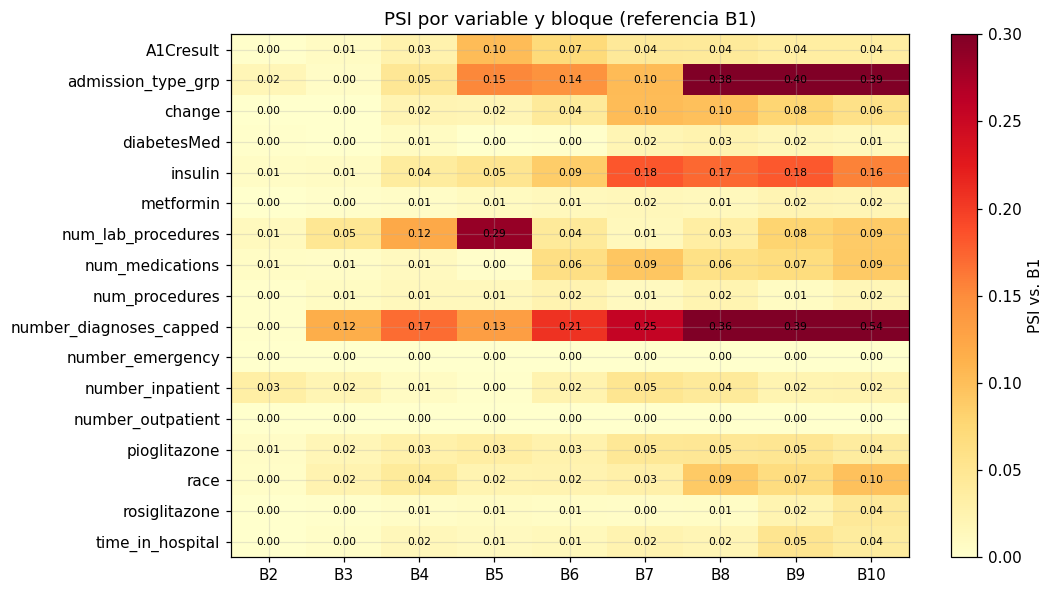

Variables con PSI > 0.25 en algún bloque: ['admission_type_grp', 'num_lab_procedures', 'number_diagnoses_capped']
Prevalencia por bloque: {1: 0.111, 2: 0.122, 3: 0.12, 4: 0.11, 5: 0.122, 6: 0.115, 7: 0.11, 8: 0.112, 9: 0.109, 10: 0.108}


In [10]:
VARS_NUM_DRIFT = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
                  "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses_capped"]
VARS_CAT_DRIFT = ["insulin", "metformin", "rosiglitazone", "pioglitazone", "A1Cresult",
                  "change", "diabetesMed", "admission_type_grp", "race"]

ref = df[df.bloque == 1]
filas = []
n_tests = (len(VARS_NUM_DRIFT) + len(VARS_CAT_DRIFT)) * (N_BLOQUES - 1)
for b in range(2, N_BLOQUES + 1):
    act = df[df.bloque == b]
    for v in VARS_NUM_DRIFT:
        pv = stats.ks_2samp(ref[v], act[v]).pvalue
        filas.append((b, v, "num", psi(ref[v], act[v]), pv))
    for v in VARS_CAT_DRIFT:
        tab = pd.crosstab(pd.concat([ref[v], act[v]]).astype(str),
                          np.r_[np.zeros(len(ref)), np.ones(len(act))])
        pv = stats.chi2_contingency(tab)[1]
        filas.append((b, v, "cat", psi(ref[v], act[v], categorica=True), pv))

drift = pd.DataFrame(filas, columns=["bloque", "variable", "tipo", "PSI", "p_valor"])
drift["significativo (Bonferroni)"] = drift.p_valor < 0.01 / n_tests
drift["estado PSI"] = drift.PSI.apply(clasificar_psi)
drift.to_csv("../resultados/drift_por_bloque.csv", index=False)

mapa = drift.pivot(index="variable", columns="bloque", values="PSI")
fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(mapa.values, cmap="YlOrRd", vmin=0, vmax=0.3, aspect="auto")
ax.set_xticks(range(mapa.shape[1]), [f"B{c}" for c in mapa.columns])
ax.set_yticks(range(mapa.shape[0]), mapa.index)
for i in range(mapa.shape[0]):
    for j in range(mapa.shape[1]):
        ax.text(j, i, f"{mapa.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, label="PSI vs. B1"); ax.set_title("PSI por variable y bloque (referencia B1)")
plt.tight_layout(); plt.savefig("../resultados/fig_psi_heatmap.png", bbox_inches="tight"); plt.show()

print("Variables con PSI > 0.25 en algún bloque:",
      sorted(drift.loc[drift.PSI > 0.25, "variable"].unique()))
print("Prevalencia por bloque:", df.groupby("bloque").y.mean().round(3).to_dict())

## 8. Estrategias de adaptación E2–E4 (ventanas fijas / disparador)

In [11]:
def entrenar_eval(bloques_train, b_test, nombre=None, ic=False):
    nombre = nombre or MODELO_PRINCIPAL
    X, y = datos_bloques(bloques_train)
    mod = ModeloCalibrado(nombre, MEJORES[nombre]).fit(X, y)
    Xb, yb = datos_bloques([b_test], EMBARGO)
    p = mod.predict_proba(Xb)
    return mod, yb.values, p, evaluar(yb, p, ic=ic)

filas = []
t0 = time.time()
for b in BLOQUES_PRUEBA:
    _, yb, p, m = entrenar_eval(list(range(1, b)), b)
    PRED[("E2", MODELO_PRINCIPAL, b)] = (yb, p)
    filas.append({"experimento": "E2 expansiva", "S": np.nan, "bloque": b, **m})
print(f"E2: {time.time()-t0:.0f}s")

for S in (1, 2, 3, 5):
    t0 = time.time()
    for b in BLOQUES_PRUEBA:
        if b - S < 1: continue
        _, yb, p, m = entrenar_eval(list(range(b - S, b)), b)
        PRED[(f"E3_S{S}", MODELO_PRINCIPAL, b)] = (yb, p)
        filas.append({"experimento": f"E3 deslizante S={S}", "S": S, "bloque": b, **m})
    print(f"E3 S={S}: {time.time()-t0:.0f}s")
res_adapt = pd.DataFrame(filas)

E2: 41s


E3 S=1: 13s


E3 S=2: 17s


E3 S=3: 20s


E3 S=5: 22s


In [12]:
VARS_CLAVE_PSI = ["number_inpatient", "num_medications", "insulin", "number_diagnoses_capped", "diag_1_grp"]
CAT_PSI = {"insulin", "diag_1_grp"}

def disparador(m_ref, m_act, X_train, X_act):
    razones = []
    if (m_ref["ROC_AUC"] - m_act["ROC_AUC"] > 0.03) and (m_act["AUC_ic_sup"] < m_ref["AUC_ic_inf"]):
        razones.append("caída AUC")
    if not (0.80 <= m_act["pendiente_cal"] <= 1.20):
        razones.append("pendiente fuera de rango")
    n_psi = sum(psi(X_train[v], X_act[v], categorica=v in CAT_PSI) > 0.25 for v in VARS_CLAVE_PSI)
    if n_psi >= 2:
        razones.append(f"PSI>0.25 en {n_psi} variables")
    return razones

# E4: comienza con el modelo de E1 y reentrena (S=3) cuando se dispara
bloques_train = list(range(1, BLOQUES_TRAIN_INICIAL + 1))
mod = ModeloCalibrado(MODELO_PRINCIPAL, MEJORES[MODELO_PRINCIPAL]).fit(*datos_bloques(bloques_train))
m_ref, filas_e4, log_e4 = None, [], []
for b in BLOQUES_PRUEBA:
    Xb, yb = datos_bloques([b], EMBARGO)
    p = mod.predict_proba(Xb)
    PRED[("E4", MODELO_PRINCIPAL, b)] = (yb.values, p)
    m = evaluar(yb, p, ic=True)
    filas_e4.append({"experimento": "E4 disparador", "S": 3, "bloque": b, "entrenado_con": str(bloques_train), **m})
    if m_ref is None:
        m_ref = m; continue           # primer bloque evaluado = referencia del modelo vigente
    razones = disparador(m_ref, m, datos_bloques(bloques_train)[0], Xb)
    if razones and b < N_BLOQUES:     # etiquetas de b disponibles -> reentrenar para b+1
        bloques_train = list(range(max(1, b - 2), b + 1))
        mod = ModeloCalibrado(MODELO_PRINCIPAL, MEJORES[MODELO_PRINCIPAL]).fit(*datos_bloques(bloques_train))
        m_ref = None
        log_e4.append({"tras_bloque": b, "razones": "; ".join(razones), "nueva_ventana": bloques_train})
res_adapt = pd.concat([res_adapt, pd.DataFrame(filas_e4)], ignore_index=True)
print("Reentrenamientos disparados:", len(log_e4))
pd.DataFrame(log_e4)

Reentrenamientos disparados: 1


,tras_bloque,razones,nueva_ventana
0,7,caída AUC,"[5, 6, 7]"


ROC_AUC        PR_AUC         Brier        pendiente_cal  \
                     mean    min   mean    min   mean    min          mean   
experimento                                                                  
E1 estático         0.662  0.643  0.212  0.190  0.097  0.093         1.028   
E2 expansiva        0.676  0.648  0.223  0.184  0.095  0.091         1.075   
E3 deslizante S=1   0.667  0.627  0.214  0.167  0.095  0.091         0.918   
E3 deslizante S=2   0.676  0.643  0.222  0.189  0.095  0.091         1.053   
E3 deslizante S=3   0.680  0.646  0.226  0.191  0.095  0.090         1.123   
E3 deslizante S=5   0.679  0.649  0.219  0.196  0.095  0.090         1.039   
E4 disparador       0.674  0.643  0.222  0.190  0.095  0.091         1.166   

                            ECE         
                     min   mean    min  
experimento                             
E1 estático        0.875  0.035  0.025  
E2 expansiva       0.862  0.014  0.008  
E3 deslizante S=1  0.300  0.015  0.008  
E3 deslizante S=2  0.822  0.014  0.006  
E3 deslizante S=3  0.938  0.015  0.009  
E3 deslizante S=5  0.896  0.014  0.006  
E4 disparador      0.875  0.023  0.012

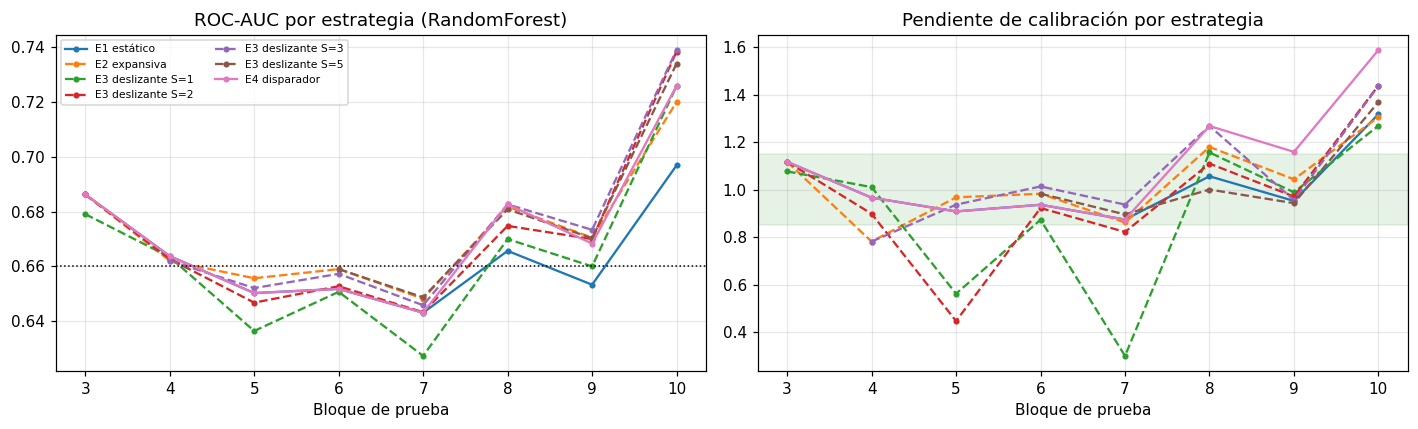

Estrategia elegida para la capa de decisión: E3 deslizante S=3


In [13]:
e1_principal = res_e1[res_e1.modelo == MODELO_PRINCIPAL].assign(experimento="E1 estático")
todo = pd.concat([e1_principal, res_adapt], ignore_index=True)
todo.to_csv("../resultados/experimentos_E1_E4.csv", index=False)

COMUNES = [b for b in BLOQUES_PRUEBA if b >= 6]   # bloques evaluados por todas las estrategias (S=5 empieza en B6)
comparacion = (todo[todo.bloque.isin(COMUNES)]
               .groupby("experimento")[["ROC_AUC", "PR_AUC", "Brier", "pendiente_cal", "ECE"]]
               .agg(["mean", "min"]).round(3))
display(comparacion)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for exp, g in todo.groupby("experimento"):
    estilo = "-" if exp.startswith(("E1", "E4")) else "--"
    axes[0].plot(g.bloque, g.ROC_AUC, estilo, marker="o", ms=3, label=exp)
    axes[1].plot(g.bloque, g.pendiente_cal, estilo, marker="o", ms=3, label=exp)
axes[0].axhline(0.66, c="k", lw=1, ls=":"); axes[0].set_title(f"ROC-AUC por estrategia ({MODELO_PRINCIPAL})")
axes[1].axhspan(0.85, 1.15, color="green", alpha=0.1); axes[1].set_title("Pendiente de calibración por estrategia")
for a in axes: a.set_xlabel("Bloque de prueba")
axes[0].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.savefig("../resultados/fig_E1_E4_estrategias.png", bbox_inches="tight"); plt.show()

# Estrategia desplegada para la capa de decisión: mejor PR-AUC en bloques comunes (entre E1, E2, E3)
cand = comparacion[("PR_AUC", "mean")].drop(index=[i for i in comparacion.index if i.startswith("E4")])
ESTRATEGIA = cand.idxmax()
print("Estrategia elegida para la capa de decisión:", ESTRATEGIA)

## 9. Granularidad del monitoreo (5, 10 y 15 bloques)

primero  ultimo  media   desv  n_bloques  caida
G  estrategia                                                 
5  E1            0.671   0.680  0.664  0.014          4 -0.008
   E3 (S=2)      0.658   0.698  0.671  0.023          3 -0.040
10 E1            0.687   0.702  0.664  0.020          8 -0.015
   E3 (S=3)      0.663   0.733  0.671  0.029          7 -0.070
15 E1            0.682   0.710  0.662  0.020         12 -0.028
   E3 (S=4)      0.672   0.752  0.672  0.030         11 -0.080

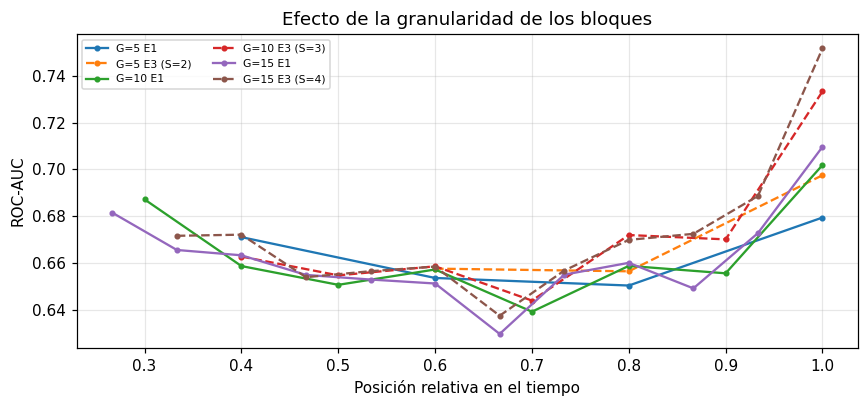

In [14]:
filas_g = []
for G in (5, 10, 15):
    marco = df.assign(bloque_g=pd.qcut(df.pos, G, labels=False) + 1)
    n_ini = max(1, round(0.2 * G)); S = max(1, round(0.3 * G))
    Xi, yi = datos_bloques(range(1, n_ini + 1), marco=marco)
    m_est = ModeloCalibrado(MODELO_PRINCIPAL, MEJORES[MODELO_PRINCIPAL]).fit(Xi, yi)
    for b in range(n_ini + 1, G + 1):
        Xb, yb = datos_bloques([b], EMBARGO, marco=marco)
        filas_g.append({"G": G, "estrategia": "E1", "pos_rel": b / G, "ROC_AUC": roc_auc_score(yb, m_est.predict_proba(Xb))})
        if b - S >= 1:
            Xs, ys = datos_bloques(range(b - S, b), marco=marco)
            m_s = ModeloCalibrado(MODELO_PRINCIPAL, MEJORES[MODELO_PRINCIPAL]).fit(Xs, ys)
            filas_g.append({"G": G, "estrategia": f"E3 (S={S})", "pos_rel": b / G, "ROC_AUC": roc_auc_score(yb, m_s.predict_proba(Xb))})
res_g = pd.DataFrame(filas_g)
res_g.to_csv("../resultados/granularidad.csv", index=False)

resumen_g = res_g.groupby(["G", "estrategia"]).ROC_AUC.agg(
    primero="first", ultimo="last", media="mean", desv="std", n_bloques="size")
resumen_g["caida"] = resumen_g.primero - resumen_g.ultimo
display(resumen_g.round(3))

fig, ax = plt.subplots(figsize=(8, 3.8))
for (G, est), g in res_g.groupby(["G", "estrategia"]):
    ax.plot(g.pos_rel, g.ROC_AUC, "-" if est == "E1" else "--", marker="o", ms=3, label=f"G={G} {est}")
ax.set_xlabel("Posición relativa en el tiempo"); ax.set_ylabel("ROC-AUC"); ax.legend(fontsize=7, ncol=2)
ax.set_title("Efecto de la granularidad de los bloques")
plt.tight_layout(); plt.savefig("../resultados/fig_granularidad.png", bbox_inches="tight"); plt.show()

## 10. Capa de decisión: incertidumbre, categorías, costos y DCA

In [15]:
CLAVE_PRED = {"E1 estático": "E1", "E2 expansiva": "E2"}
def clave(estr):
    return CLAVE_PRED.get(estr) or "E3_S" + estr.split("S=")[1]

def ventana(estr, b):
    if estr.startswith("E1"): return list(range(1, BLOQUES_TRAIN_INICIAL + 1))
    if estr.startswith("E2"): return list(range(1, b))
    S = int(estr.split("S=")[1]); return list(range(b - S, b))

def asignar(p, lo, hi, t1, t2, k=K_ALTO):
    n = len(p); cat = np.full(n, "Bajo", dtype=object)
    cat[p >= t1] = "Moderado"
    cand = np.where(p >= t2)[0]
    orden = cand[np.argsort(-p[cand])]
    cupo = int(np.floor(k * n))
    cat[orden[:cupo]] = "Alto"
    prioridad = np.zeros(n, bool); prioridad[orden[cupo:]] = True
    incierto = ((lo < t1) & (hi >= t1)) | ((lo < t2) & (hi >= t2))
    return cat, prioridad, incierto

def costo_categorias(y, cat, e=E, e_m=E_M, c_r=C_R):
    y = np.asarray(y)
    c = np.where(cat == "Alto", C_I + c_r * y * (1 - e),
                 np.where(cat == "Moderado", C_M + c_r * y * (1 - e_m), c_r * y))
    return 1000 * c.mean()

In [16]:
bloques_dec = [b for b in BLOQUES_PRUEBA if min(ventana(ESTRATEGIA, b)) >= 1]
cache, filas_dec = {}, []
t0 = time.time()
for b in bloques_dec:
    w = tuple(ventana(ESTRATEGIA, b))
    if w not in cache:
        Xw, yw = datos_bloques(list(w))
        principal = ModeloCalibrado(MODELO_PRINCIPAL, MEJORES[MODELO_PRINCIPAL]).fit(Xw, yw)
        replicas = [ModeloCalibrado(MODELO_PRINCIPAL, MEJORES[MODELO_PRINCIPAL], semilla=i, bootstrap=True).fit(Xw, yw)
                    for i in range(N_REPLICAS_INCERT)]
        cache = {w: (principal, replicas)}   # solo se guarda la ventana vigente
    principal, replicas = cache[w]
    Xb, yb = datos_bloques([b], EMBARGO)
    p = principal.predict_proba(Xb)
    R = np.column_stack([r.predict_proba(Xb) for r in replicas])
    lo, hi = np.percentile(R, 5, axis=1), np.percentile(R, 95, axis=1)
    filas_dec.append(pd.DataFrame({"bloque": b, "y": yb.values, "p": p, "lo": lo, "hi": hi,
                                   "race": df.loc[Xb.index, "race"].values,
                                   "edad": df.loc[Xb.index, "edad"].values}))
dec = pd.concat(filas_dec, ignore_index=True)
print(f"Simulación de decisión ({ESTRATEGIA}, {len(bloques_dec)} bloques, {N_REPLICAS_INCERT} réplicas): {time.time()-t0:.0f}s")

Simulación de decisión (E3 deslizante S=3, 7 bloques, 10 réplicas): 225s


In [17]:
def simular(e=E, c_r=C_R):
    t1, t2 = umbrales(c_r=c_r, e=e)
    out = []
    for b, g in dec.groupby("bloque"):
        cat, prio, inc = asignar(g.p.values, g.lo.values, g.hi.values, t1, t2)
        out.append(g.assign(cat=cat, prioridad=prio, incierto=inc))
    return pd.concat(out), t1, t2

def tabla_costos(e=E, c_r=C_R, etiqueta=""):
    d, t1, t2 = simular(e, c_r)
    filas = []
    for b, g in d.groupby("bloque"):
        y = g.y.values
        filas.append({"bloque": b,
                      "Modelo (3 categorías)": costo_categorias(y, g.cat.values, e=e, c_r=c_r),
                      "No intervenir": 1000 * c_r * y.mean(),
                      "Intervenir a todos": costo_categorias(y, np.full(len(y), "Alto", dtype=object), e=e, c_r=c_r),
                      "Modelo binario (p ≥ p*, sin cupo)": costo_por_1000(y, g.p.values >= p_estrella(e=e, c_r=c_r), e=e, c_r=c_r)})
    t = pd.DataFrame(filas).set_index("bloque")
    r = t.mean().to_frame(f"{etiqueta} (t1={t1:.2f}, t2={t2:.2f})").T
    r["Ahorro vs mejor referencia"] = r[["No intervenir", "Intervenir a todos"]].min(axis=1) - r["Modelo (3 categorías)"]
    return d, t, r

dec_base, costos_bloque, r_base = tabla_costos(etiqueta="Base e=0.18")
sens = [tabla_costos(e=e, etiqueta=f"e={e}")[2] for e in E_SENSIBILIDAD]
ocup = tabla_costos(c_r=C_R * FACTOR_OCUPACION, etiqueta="Ocupación >85%")[2]
tabla_costos_final = pd.concat([r_base] + sens + [ocup])
tabla_costos_final.to_csv("../resultados/costos_politicas.csv")
print("Costo esperado promedio por 1,000 altas (US$):")
tabla_costos_final.round(0)

Costo esperado promedio por 1,000 altas (US$):


,Modelo (3 categorías),No intervenir,Intervenir a todos,"Modelo binario (p ≥ p*, sin cupo)",Ahorro vs mejor referencia
"Base e=0.18 (t1=0.10, t2=0.21)",1797592.0,1822600.0,2044532.0,1807089.0,25008.0
"e=0.12 (t1=0.10, t2=0.35)",1806584.0,1822600.0,2153888.0,1819168.0,16016.0
"e=0.18 (t1=0.10, t2=0.21)",1797592.0,1822600.0,2044532.0,1807089.0,25008.0
"e=0.38 (t1=0.10, t2=0.09)",1688841.0,1822600.0,1680012.0,1600345.0,-8829.0
"Ocupación >85% (t1=0.08, t2=0.17)",2224893.0,2278250.0,2418165.0,2230297.0,53357.0


In [18]:
d = dec_base
dist = d.cat.value_counts(normalize=True).reindex(["Bajo", "Moderado", "Alto"])
tasa_real = d.groupby("cat").y.mean().reindex(["Bajo", "Moderado", "Alto"])
recall_alto = ((d.cat == "Alto") & (d.y == 1)).sum() / d.y.sum()
impacto = E * recall_alto
pct_incierto = d.incierto.mean()
tasa_alto_bloque = d.groupby("bloque").cat.apply(lambda s: (s == "Alto").mean())

display(pd.DataFrame({"% pacientes": dist, "tasa real de reingreso": tasa_real}).style.format("{:.1%}"))
print(f"Recall de Alto Riesgo: {recall_alto:.1%} -> impacto proyectado = e × recall = {impacto:.1%}")
print(f"Tasa máx. de Alto por bloque: {tasa_alto_bloque.max():.1%} (cupo {K_ALTO:.0%}) | "
      f"con prioridad desbordada: {d.prioridad.mean():.1%}")
print(f"% Incertidumbre Alta: {pct_incierto:.1%}")

,% pacientes,tasa real de reingreso
cat,,
Bajo,52.6%,6.5%
Moderado,38.1%,14.6%
Alto,9.3%,25.4%


Recall de Alto Riesgo: 20.9% -> impacto proyectado = e × recall = 3.8%
Tasa máx. de Alto por bloque: 15.0% (cupo 15%) | con prioridad desbordada: 0.5%
% Incertidumbre Alta: 37.6%


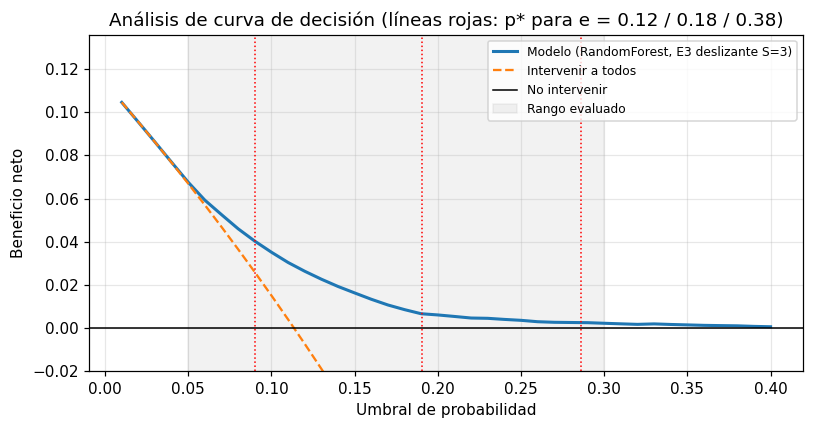

DCA: el modelo supera a ambas referencias en 100% del rango 0.05–0.30 | criterio cumplido: True


In [19]:
pts = np.round(np.arange(0.01, 0.41, 0.01), 2)
prev = d.y.mean()
nb_mod = np.array([beneficio_neto(d.y, d.p, pt) for pt in pts])
nb_todos = prev - (1 - prev) * pts / (1 - pts)
rango = (pts >= 0.05) & (pts <= 0.30)
mejor_ref = np.maximum(nb_todos, 0)
dca_ok = bool(np.all(nb_mod[rango] >= mejor_ref[rango] - 1e-9) and np.any(nb_mod[rango] > mejor_ref[rango]))
frac_supera = np.mean(nb_mod[rango] > mejor_ref[rango] + 1e-9)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(pts, nb_mod, lw=2, label=f"Modelo ({MODELO_PRINCIPAL}, {ESTRATEGIA})")
ax.plot(pts, nb_todos, "--", label="Intervenir a todos")
ax.axhline(0, c="k", lw=1, label="No intervenir")
ax.axvspan(0.05, 0.30, color="grey", alpha=0.1, label="Rango evaluado")
for e in E_SENSIBILIDAD:
    ax.axvline(p_estrella(e=e), c="r", ls=":", lw=1)
ax.set_ylim(-0.02, max(0.05, nb_mod.max() * 1.3)); ax.set_xlabel("Umbral de probabilidad"); ax.set_ylabel("Beneficio neto")
ax.set_title("Análisis de curva de decisión (líneas rojas: p* para e = 0.12 / 0.18 / 0.38)")
ax.legend(fontsize=8); plt.tight_layout(); plt.savefig("../resultados/fig_DCA.png", bbox_inches="tight"); plt.show()
print(f"DCA: el modelo supera a ambas referencias en {frac_supera:.0%} del rango 0.05–0.30 | criterio cumplido: {dca_ok}")

## 11. Auditoría de equidad

In [20]:
MIN_POS = 100
d = dec_base.assign(grupo_edad=np.where(dec_base.edad >= 70, "≥70", "<70"))

def fnr(s): return np.mean(s.cat.values[s.y.values == 1] != "Alto")

def auditar(col, ref):
    filas = []
    base = d[d[col] == ref]
    for g, s in d.groupby(col):
        n_pos = int(s.y.sum())
        fila = {"dimensión": col, "grupo": g, "n": len(s), "reingresos": n_pos,
                "evaluable": n_pos >= MIN_POS, "tasa_reingreso": s.y.mean(),
                "tasa_selección_Alto": (s.cat == "Alto").mean(), "FNR": fnr(s)}
        if n_pos >= MIN_POS:
            fila["razón_FNR"] = fnr(s) / fnr(base)
            r = np.random.default_rng(SEED); vals = []
            ps, pb = s[s.y == 1], base[base.y == 1]
            for _ in range(B_BOOT):
                a = ps.iloc[r.integers(0, len(ps), len(ps))]; c = pb.iloc[r.integers(0, len(pb), len(pb))]
                vals.append(fnr(a) / fnr(c))
            fila["razón_FNR_ic_inf"], fila["razón_FNR_ic_sup"] = np.percentile(vals, [2.5, 97.5])
            fila["pendiente_cal"], fila["intercepto_cal"] = pendiente_intercepto(s.y.values, s.p.values)
        filas.append(fila)
    return pd.DataFrame(filas)

equidad = pd.concat([auditar("grupo_edad", "<70"), auditar("race", "Caucasian")], ignore_index=True)
equidad["cumple_FNR"] = equidad.razón_FNR.between(0.87, 1.15)
equidad["cumple_calibración"] = equidad.pendiente_cal.between(0.80, 1.20) & (equidad.intercepto_cal.abs() <= 0.20)
equidad.to_csv("../resultados/equidad.csv", index=False)
display(equidad.round(3))

sel_razones = {}
for dim, g in equidad[equidad.evaluable].groupby("dimensión"):
    sel_razones[dim] = {"razón_selección (mín/máx)": g.tasa_selección_Alto.min() / g.tasa_selección_Alto.max(),
                        "razón_tasa_real (mín/máx)": g.tasa_reingreso.min() / g.tasa_reingreso.max()}
sel_razones = pd.DataFrame(sel_razones).T
display(sel_razones.round(3))
print("Grupos excluidos por tener < 100 reingresos:", equidad.loc[~equidad.evaluable, "grupo"].tolist())

,dimensión,grupo,n,reingresos,evaluable,tasa_reingreso,tasa_selección_Alto,FNR,razón_FNR,razón_FNR_ic_inf,razón_FNR_ic_sup,pendiente_cal,intercepto_cal,cumple_FNR,cumple_calibración
0,grupo_edad,<70,27863,2967,True,0.106,0.098,0.748,1.000,0.965,1.027,1.052,-0.042,True,True
1,grupo_edad,≥70,23636,2880,True,0.122,0.088,0.836,1.118,1.087,1.144,0.925,-0.018,True,True
2,race,AfricanAmerican,9186,1018,True,0.111,0.117,0.774,0.975,0.941,1.010,0.847,-0.088,True,True
3,race,Asian,375,31,False,0.083,0.043,0.806,NaN,NaN,NaN,NaN,NaN,False,False
4,race,Caucasian,38999,4514,True,0.116,0.091,0.794,1.000,0.979,1.020,1.032,-0.015,True,True
5,race,Desconocido,1096,102,True,0.093,0.044,0.912,1.148,1.080,1.219,0.962,-0.057,True,True
6,race,Hispanic,1012,98,False,0.097,0.063,0.714,NaN,NaN,NaN,NaN,NaN,False,False
7,race,Other,831,84,False,0.101,0.065,0.798,NaN,NaN,NaN,NaN,NaN,False,False


,razón_selección (mín/máx),razón_tasa_real (mín/máx)
grupo_edad,0.902,0.874
race,0.375,0.804


Grupos excluidos por tener < 100 reingresos: ['Asian', 'Hispanic', 'Other']


## 12. Explicabilidad (SHAP) y latencia

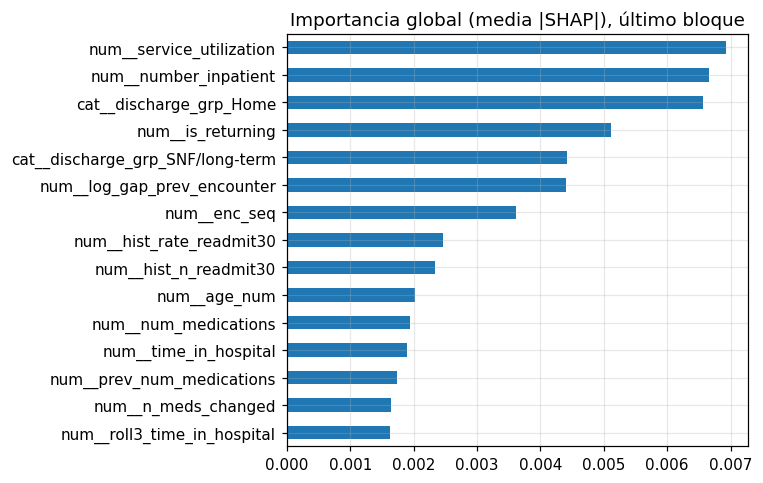

,riesgo calibrado,"top-3 variables (dirección, magnitud)"
mayor riesgo,0.536,num__number_inpatient (+0.07); num__enc_seq (+...
riesgo mediano,0.090,cat__discharge_grp_Home (+0.01); num__service_...
menor riesgo,0.030,cat__discharge_grp_Home (−0.01); num__number_i...


Predicciones con al menos 3 variables explicativas: 100.0%


In [21]:
import shap
modelo_final = cache[tuple(ventana(ESTRATEGIA, bloques_dec[-1]))][0]
Xult, _ = datos_bloques([bloques_dec[-1]], EMBARGO)
pre, clf = modelo_final.pipe.named_steps["pre"], modelo_final.pipe.named_steps["clf"]
Xt = pre.transform(Xult)
Xt = Xt.toarray() if hasattr(Xt, "toarray") else np.asarray(Xt)

if MODELO_PRINCIPAL == "ElasticNet":
    nombres = list(pre.get_feature_names_out())
    sv = shap.LinearExplainer(clf, Xt).shap_values(Xt)
else:
    nombres = list(pre.get_feature_names_out())
    if MODELO_PRINCIPAL == "RandomForest":
        Xt = Xt[:500]; Xult = Xult.iloc[:500]
    sv = shap.TreeExplainer(clf).shap_values(Xt)
sv = sv[1] if isinstance(sv, list) else sv
sv = sv[:, :, 1] if sv.ndim == 3 else sv

imp_global = pd.Series(np.abs(sv).mean(axis=0), index=nombres).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
imp_global.head(15)[::-1].plot.barh(ax=ax); ax.set_title("Importancia global (media |SHAP|), último bloque")
plt.tight_layout(); plt.savefig("../resultados/fig_shap_global.png", bbox_inches="tight"); plt.show()

def top3(i):
    idx = np.argsort(-np.abs(sv[i]))[:3]
    return "; ".join(f"{nombres[j]} ({'+' if sv[i, j] > 0 else '−'}{abs(sv[i, j]):.2f})" for j in idx)

cobertura_expl = np.mean((np.abs(sv) > 0).sum(axis=1) >= 3)
p_ult = modelo_final.predict_proba(Xult)
ejemplos = np.argsort(-p_ult)[[0, len(p_ult) // 2, -1]]
display(pd.DataFrame({"riesgo calibrado": p_ult[ejemplos].round(3),
                      "top-3 variables (dirección, magnitud)": [top3(i) for i in ejemplos]},
                     index=["mayor riesgo", "riesgo mediano", "menor riesgo"]))
print(f"Predicciones con al menos 3 variables explicativas: {cobertura_expl:.1%}")

In [22]:
tiempos = []
muestra = Xult.sample(200, random_state=SEED)
for i in range(len(muestra)):
    t = time.perf_counter()
    modelo_final.predict_proba(muestra.iloc[[i]])
    tiempos.append((time.perf_counter() - t) * 1000)
lat_p95 = np.percentile(tiempos, 95)
cobertura_pred = np.isfinite(dec_base.p).mean()
print(f"Latencia por paciente: mediana {np.median(tiempos):.1f} ms | p95 {lat_p95:.1f} ms")
print(f"Cobertura de predicción: {cobertura_pred:.1%}")

Latencia por paciente: mediana 63.6 ms | p95 79.5 ms
Cobertura de predicción: 100.0%


## 13. Tabla resumen de criterios de aprobación

In [23]:
t = todo[todo.experimento == ESTRATEGIA]
m_prom, m_peor = t.mean(numeric_only=True), t.min(numeric_only=True)
ok = lambda c: "✔" if c else "✘"
n_eval_edad = equidad[(equidad.dimensión == "grupo_edad") & equidad.evaluable & (equidad.grupo != "<70")]
n_eval_raza = equidad[(equidad.dimensión == "race") & equidad.evaluable & (equidad.grupo != "Caucasian")]
sel_min = sel_razones["razón_selección (mín/máx)"].min()
calib_sub_ok = equidad.loc[equidad.evaluable, "cumple_calibración"].all()
cost_ok_sens = all(r["Ahorro vs mejor referencia"].iloc[0] > 0 for r in sens)

resumen = pd.DataFrame([
    ["Técnica", "ROC-AUC", "≥ 0.66", f"{m_prom.ROC_AUC:.3f} (peor {m_peor.ROC_AUC:.3f})", ok(m_prom.ROC_AUC >= 0.66)],
    ["Técnica", "PR-AUC / lift", "≥ 0.20 y ≥ 1.8×", f"{m_prom.PR_AUC:.3f} / {m_prom.lift_PR:.2f}×", ok(m_prom.PR_AUC >= 0.20 and m_prom.lift_PR >= 1.8)],
    ["Técnica", "Brier", "≤ 0.095", f"{m_prom.Brier:.4f} (BSS {m_prom.BSS:.3f})", ok(m_prom.Brier <= 0.095)],
    ["Técnica", "Pendiente de calibración", "[0.85, 1.15]", f"{m_prom.pendiente_cal:.2f} (rango {t.pendiente_cal.min():.2f}–{t.pendiente_cal.max():.2f})", ok(0.85 <= m_prom.pendiente_cal <= 1.15)],
    ["Técnica", "Intercepto de calibración", "[−0.15, 0.15]", f"{m_prom.intercepto_cal:.3f}", ok(abs(m_prom.intercepto_cal) <= 0.15)],
    ["Técnica", "ECE", "≤ 0.02", f"{m_prom.ECE:.4f}", ok(m_prom.ECE <= 0.02)],
    ["Técnica", "Latencia p95", "< 1,000 ms", f"{lat_p95:.1f} ms", ok(lat_p95 < 1000)],
    ["Decisión", "Beneficio neto (DCA)", "≥ referencias en 0.05–0.30", f"supera en {frac_supera:.0%} del rango", ok(dca_ok)],
    ["Decisión", "Costo esperado (base)", "< mín(referencias)", f"ahorro US${r_base['Ahorro vs mejor referencia'].iloc[0]:,.0f} / 1,000 altas", ok(r_base["Ahorro vs mejor referencia"].iloc[0] > 0)],
    ["Decisión", "Costo esperado (sensibilidad e)", "< mín(referencias) para e ∈ {0.12, 0.18, 0.38}", " / ".join(f"{r['Ahorro vs mejor referencia'].iloc[0]:,.0f}" for r in sens), ok(cost_ok_sens)],
    ["Decisión", "Impacto proyectado", "≥ 5%", f"{impacto:.1%}", ok(impacto >= 0.05)],
    ["Decisión", "Tasa de Alto por bloque", f"≤ {K_ALTO:.0%}", f"{tasa_alto_bloque.max():.1%}", ok(tasa_alto_bloque.max() <= K_ALTO + 1e-9)],
    ["Decisión", "Tiempo de respuesta", "≥ 90% contactados ≤ 7 días", "N/A (despliegue)", "—"],
    ["Social", "Razón FNR edad (≥70 vs <70)", "[0.87, 1.15]", "; ".join(f"{r.grupo}: {r.razón_FNR:.2f} [{r.razón_FNR_ic_inf:.2f}–{r.razón_FNR_ic_sup:.2f}]" for r in n_eval_edad.itertuples()), ok(n_eval_edad.cumple_FNR.all())],
    ["Social", "Razón FNR raza (vs Caucasian)", "[0.87, 1.15], ≥100 reingresos", "; ".join(f"{r.grupo}: {r.razón_FNR:.2f}" for r in n_eval_raza.itertuples()), ok(n_eval_raza.cumple_FNR.all())],
    ["Social", "Razón de selección (80%)", "≥ 0.80", f"{sel_min:.2f}", ok(sel_min >= 0.80)],
    ["Social", "Calibración por subgrupo", "pendiente [0.8, 1.2], |int.| ≤ 0.2", "ver tabla de equidad", ok(calib_sub_ok)],
    ["Social", "Cobertura", "≥ 98%", f"{cobertura_pred:.1%}", ok(cobertura_pred >= 0.98)],
    ["Social", "Incertidumbre Alta", "≤ 15%", f"{pct_incierto:.1%}", ok(pct_incierto <= 0.15)],
    ["Social", "Reingreso en categoría Bajo", "< 8%", f"{tasa_real['Bajo']:.1%}", ok(tasa_real["Bajo"] < 0.08)],
    ["Social", "Explicabilidad top-3", "100%", f"{cobertura_expl:.1%}", ok(cobertura_expl >= 0.999)],
    ["Monitoreo", "Reentrenamientos disparados (E4)", "informativo", f"{len(log_e4)}", "—"],
    ["Monitoreo", "Variables con PSI > 0.25 (vs B1)", "informativo", ", ".join(sorted(drift.loc[drift.PSI > 0.25, 'variable'].unique())) or "ninguna", "—"],
], columns=["Dimensión", "Métrica", "Criterio", "Resultado", "Cumple"])
resumen.to_csv("../resultados/resumen_criterios.csv", index=False)
print(f"Modelo principal: {MODELO_PRINCIPAL} | Estrategia: {ESTRATEGIA}")
resumen

Modelo principal: RandomForest | Estrategia: E3 deslizante S=3


,Dimensión,Métrica,Criterio,Resultado,Cumple
0,Técnica,ROC-AUC,≥ 0.66,0.673 (peor 0.646),✔
1,Técnica,PR-AUC / lift,≥ 0.20 y ≥ 1.8×,0.220 / 1.94×,✔
2,Técnica,Brier,≤ 0.095,0.0963 (BSS 0.044),✘
3,Técnica,Pendiente de calibración,"[0.85, 1.15]",1.05 (rango 0.78–1.44),✔
4,Técnica,Intercepto de calibración,"[−0.15, 0.15]",-0.031,✔
5,Técnica,ECE,≤ 0.02,0.0144,✔
6,Técnica,Latencia p95,"< 1,000 ms",79.5 ms,✔
7,Decisión,Beneficio neto (DCA),≥ referencias en 0.05–0.30,supera en 100% del rango,✔
8,Decisión,Costo esperado (base),< mín(referencias),"ahorro US$25,008 / 1,000 altas",✔
9,Decisión,Costo esperado (sensibilidad e),"< mín(referencias) para e ∈ {0.12, 0.18, 0.38}","16,016 / 25,008 / -8,829",✘


## 14. Caso de negocio: valor económico del monitoreo de drift

Costo esperado SIN monitoreo (estático, umbral fijo): US$90,268,164 / año
Costo esperado CON monitoreo adaptativo (E3 deslizante S=3):  US$89,879,592 / año
Ahorro bruto atribuible al monitoreo de drift:          US$388,573 / año
Costo de mantenimiento del sistema (monitoreo + reentrenos): US$3,406 / año
Beneficio neto:                                          US$385,167 / año  (ROI = 113.1x)


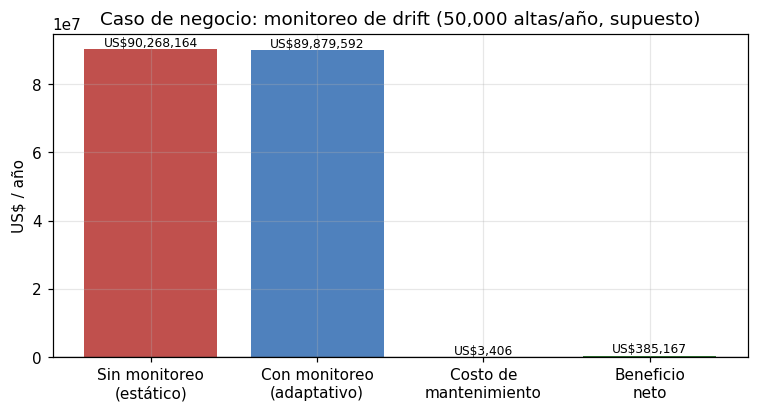

In [24]:
# --- Modelo estático "desplegado y olvidado" (sin monitoreo de drift, umbrales fijos desde B1-B2) ---
Xini, yini = datos_bloques(list(range(1, BLOQUES_TRAIN_INICIAL + 1)))
mod_estatico = ModeloCalibrado(MODELO_PRINCIPAL, MEJORES[MODELO_PRINCIPAL]).fit(Xini, yini)
t1_fijo, t2_fijo = umbrales()   # calibrados una sola vez; nunca se re-derivan (caso "sin monitoreo")

filas_estatico = []
for b in bloques_dec:
    Xb, yb = datos_bloques([b], EMBARGO)
    p = mod_estatico.predict_proba(Xb)
    cat, _, _ = asignar(p, p, p, t1_fijo, t2_fijo)
    filas_estatico.append({"bloque": b, "costo_1000_sin_monitoreo": costo_categorias(yb.values, cat)})
costo_estatico = pd.DataFrame(filas_estatico)

costo_adaptativo = (dec_base.groupby("bloque")
                    .apply(lambda g: costo_categorias(g.y.values, g.cat.values))
                    .rename("costo_1000_con_monitoreo").reset_index())

comp = costo_estatico.merge(costo_adaptativo, on="bloque")
comp["ahorro_1000"] = comp.costo_1000_sin_monitoreo - comp.costo_1000_con_monitoreo
comp.to_csv("../resultados/caso_negocio_por_bloque.csv", index=False)

ahorro_1000_prom = comp.ahorro_1000.mean()
costo_sin_prom = comp.costo_1000_sin_monitoreo.mean()
costo_con_prom = comp.costo_1000_con_monitoreo.mean()

# --- Escala anual (supuesto ilustrativo; ver justificación en el informe) ---
ALTAS_ANUALES = 50_000  # [Supuesto] red hospitalaria mediana-grande; dataset fuente: Strack et al. (2014), ~101,766 altas / 130 hospitales / 10 años
ahorro_anual = ahorro_1000_prom * (ALTAS_ANUALES / 1000)
costo_sin_anual = costo_sin_prom * (ALTAS_ANUALES / 1000)
costo_con_anual = costo_con_prom * (ALTAS_ANUALES / 1000)

# --- Costo de mantenimiento del sistema de monitoreo/adaptación [Supuestos, ver informe] ---
TARIFA_HORA = 70.0          # US$/hora de un data scientist / ML engineer [Supuesto]
HORAS_MONITOREO_MES = 3.0   # revisión mensual de PSI/KS/calibración por subgrupo [Supuesto]
COSTO_COMPUTO_MONITOREO_MES = 60.0  # cómputo batch (PSI/KS/ROC-AUC) + almacenamiento [Supuesto]
HORAS_POR_REENTRENO = 16.0  # re-tuning + validación + despliegue por evento disparado [Supuesto]
COSTO_COMPUTO_REENTRENO = 40.0      # cómputo de un reentrenamiento [Supuesto]
N_BLOQUES_EVALUADOS = len(bloques_dec)
TASA_REENTRENOS_ANUAL = len(log_e4) / N_BLOQUES_EVALUADOS  # eventos E4 por bloque pseudo-anual evaluado

costo_monitoreo_anual = 12 * (HORAS_MONITOREO_MES * TARIFA_HORA + COSTO_COMPUTO_MONITOREO_MES)
costo_reentreno_anual = TASA_REENTRENOS_ANUAL * (HORAS_POR_REENTRENO * TARIFA_HORA + COSTO_COMPUTO_REENTRENO)
costo_mantenimiento_anual = costo_monitoreo_anual + costo_reentreno_anual

beneficio_neto_anual = ahorro_anual - costo_mantenimiento_anual
roi = beneficio_neto_anual / costo_mantenimiento_anual if costo_mantenimiento_anual else np.nan

resumen_negocio = pd.DataFrame([{
    "altas_anuales_supuesto": ALTAS_ANUALES,
    "costo_sin_monitoreo_anual_usd": costo_sin_anual,
    "costo_con_monitoreo_anual_usd": costo_con_anual,
    "ahorro_bruto_anual_usd": ahorro_anual,
    "costo_mantenimiento_anual_usd": costo_mantenimiento_anual,
    "beneficio_neto_anual_usd": beneficio_neto_anual,
    "roi_x": roi,
}]).T.rename(columns={0: "valor"})
resumen_negocio.to_csv("../resultados/caso_negocio_resumen.csv")

print(f"Costo esperado SIN monitoreo (estático, umbral fijo): US${costo_sin_anual:,.0f} / año")
print(f"Costo esperado CON monitoreo adaptativo ({ESTRATEGIA}):  US${costo_con_anual:,.0f} / año")
print(f"Ahorro bruto atribuible al monitoreo de drift:          US${ahorro_anual:,.0f} / año")
print(f"Costo de mantenimiento del sistema (monitoreo + reentrenos): US${costo_mantenimiento_anual:,.0f} / año")
print(f"Beneficio neto:                                          US${beneficio_neto_anual:,.0f} / año  (ROI = {roi:.1f}x)")

fig, ax = plt.subplots(figsize=(7, 4))
barras = ["Sin monitoreo\n(estático)", "Con monitoreo\n(adaptativo)", "Costo de\nmantenimiento", "Beneficio\nneto"]
valores = [costo_sin_anual, costo_con_anual, costo_mantenimiento_anual, beneficio_neto_anual]
colores = ["#c0504d", "#4f81bd", "#8064a2", "#2e7d32"]
ax.bar(barras, valores, color=colores)
for i, v in enumerate(valores):
    ax.text(i, v, f"US${v:,.0f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=8)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("US$ / año"); ax.set_title(f"Caso de negocio: monitoreo de drift ({ALTAS_ANUALES:,} altas/año, supuesto)")
plt.tight_layout(); plt.savefig("../resultados/fig_caso_negocio.png", bbox_inches="tight"); plt.show()
